In [1]:
%load_ext IPython.extensions.autoreload
%autoreload 2
from latham.simulation import *
from latham.params import *
import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl
import gzip

In [3]:
excitatory_firing_rates = []
inhib_firing_rates = []

for I in np.linspace(2.5, 5, 14):
    print("-----------------")
    cell_params, synaptic_params, network_params = network_B(I, 1.4, 1.0, 0)

    pkl_path = f"pkls/fig10/I-{I}.pkl.gzip"
    
    res = None
    
    #res = run_sim(cell_params, synaptic_params, network_params, random_seed=1)
    #with gzip.open(pkl_path, "wb") as f:
    #    pkl.dump(res, f)
    
    with gzip.open(pkl_path, "rb") as f:
        res = pkl.load(f)

    _, spikes, final_state = res
        
    excitatory_firing_rate = spikes[:,final_state.neuron_types].sum() / 100 / network_params.n / (1 - network_params.inhib_fraction)
    inhib_firing_rate = spikes[:,~final_state.neuron_types].sum() / 100 / network_params.n / network_params.inhib_fraction
    excitatory_firing_rates.append(excitatory_firing_rate)
    inhib_firing_rates.append(inhib_firing_rate)
    print(f"Excitatory firing rate: {excitatory_firing_rate}")
    print(f"Inhibitory firing rate: {inhib_firing_rate}")
    

-----------------
Excitatory firing rate: 0.0023771428571428576
Inhibitory firing rate: 0.005393333333333333
-----------------
Excitatory firing rate: 0.002821428571428572
Inhibitory firing rate: 0.006403333333333334
-----------------
Excitatory firing rate: 0.19576428571428572
Inhibitory firing rate: 0.47090000000000004
-----------------
Excitatory firing rate: 0.45917571428571435
Inhibitory firing rate: 1.0844766666666668
-----------------
Excitatory firing rate: 0.529897142857143
Inhibitory firing rate: 1.2389166666666667
-----------------
Excitatory firing rate: 0.5951028571428572
Inhibitory firing rate: 1.3754533333333332
-----------------
Excitatory firing rate: 0.6574514285714286
Inhibitory firing rate: 1.4977866666666666
-----------------
Excitatory firing rate: 0.6999942857142858
Inhibitory firing rate: 1.5863333333333334
-----------------
Excitatory firing rate: 0.7486385714285715
Inhibitory firing rate: 1.6784933333333334
-----------------
Excitatory firing rate: 0.79662
Inh

NetworkParams {n: 10000, delta_r: 0.1, excit_rev_pot: 0, inhib_rev_pot: -80, b_e: 1.4, b_i: 1.0, inhib_fraction: 0.3, k_e: 200, k_i: 200, sigma_e: 0.12, sigma_i: 0.12, v_epsp: 4, v_ipsp: -6}


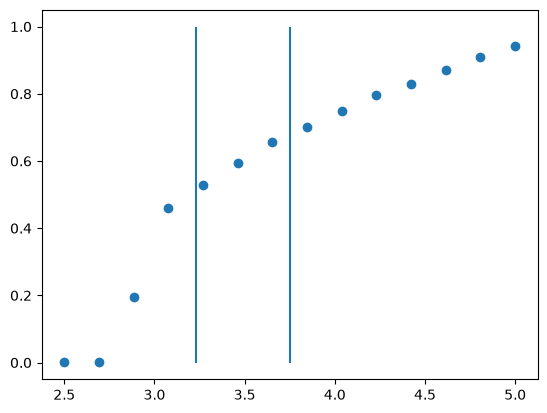

In [5]:
print(network_params)
plt.scatter(np.linspace(2.5,5, 14), np.array(excitatory_firing_rates))
plt.vlines([3.23, 3.75], 0, 1)

In [2]:
high_excitatory_firing_rates = []
low_excitatory_firing_rates = []

for I in np.linspace(2.5, 5, 14):
    print("--------------")
    print(f"I = {I}")
    cell_params, synaptic_params, network_params = network_B(I, 1.4, 1.0, 0.08)
    
    res = None
    pkl_path = f"pkls/fig10/SA-I-{I}.pkl.gzip"
    
    res = run_sim(cell_params, synaptic_params, network_params)
    with gzip.open(pkl_path, "wb") as f:
        pkl.dump(res, f)
    
    #with gzip.open(pkl_path, "rb") as f:
    #    res = pkl.load(f)

    t, spikes, final_state = res

    activity = spikes.sum(axis=1)
    # use a rolling average to smooth out noise and find bursting windows
    bursting_filter = np.sum(np.lib.stride_tricks.sliding_window_view(activity, window_shape=101), axis=1) > 0
    # say somewhat arbitrarily that if we see activity windows after 50s that there exists a stable/metastable state
    # and that if there is a total period of >1s of silence after 50s that that means bursting
    if np.any(bursting_filter[50000:]) and np.sum(~bursting_filter[50000:]) >= 1000:
        print("Bursting")
        bursts = spikes[50:-50][bursting_filter,]
        excitatory_firing_rate = bursts[:,final_state.neuron_types].sum() / (bursts.shape[0] / 1000) / network_params.n / (1 - network_params.inhib_fraction)
        high_excitatory_firing_rates.append(excitatory_firing_rate)
        low_excitatory_firing_rates.append(0)
    else:
        excitatory_firing_rate = spikes[:,final_state.neuron_types].sum() / 100 / network_params.n / (1 - network_params.inhib_fraction)
        high_excitatory_firing_rates.append(excitatory_firing_rate)
        low_excitatory_firing_rates.append(None)
    print(excitatory_firing_rate)

--------------
I = 2.5
Successfully initialised simulation.


100001it [02:21, 704.38it/s]                                                                                                                                                                                


0.00823
--------------
I = 2.6923076923076925
Successfully initialised simulation.


100001it [02:21, 705.81it/s]                                                                                                                                                                                


0.013118571428571429
--------------
I = 2.8846153846153846
Successfully initialised simulation.


...

Bursting
0.6316430215002778
--------------
I = 4.807692307692308
Successfully initialised simulation.


100001it [03:25, 486.87it/s]                                                                                                                                                                                


0.6642014285714286
--------------
I = 5.0
Successfully initialised simulation.


100001it [03:23, 492.26it/s]                                                                                                                                                                                


0.6917485714285715


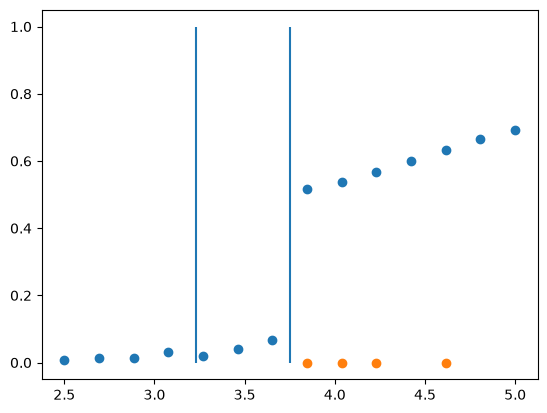

In [3]:
plt.scatter(np.linspace(2.5,5, 14), np.array(high_excitatory_firing_rates))
plt.scatter(np.linspace(2.5,5, 14), np.array(low_excitatory_firing_rates))
plt.vlines([3.23, 3.75], 0, 1)